In [4]:
!pip install netCDF4
!pip install cartopy

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob


In [5]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as pl
import glob
import time
from datetime import datetime, timedelta
from matplotlib.dates import date2num, num2date
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import numpy.ma as ma
from scipy.interpolate import griddata
from sklearn.linear_model import LinearRegression

In [6]:
filelist = glob.glob("./*.nc")

In [7]:
filelist = np.sort(filelist)

## <span style="color:darkblue">Loading one file to run some tests</span>

In [8]:
f = nc.Dataset(filelist[-1],'r')
#
SST = f.variables['SST'][:]; TLAT = f.variables['TLAT'][:]; TLONG = f.variables['TLONG'][:]
#
t = f.variables['time'][:]

SST, TLAT, TLONG, time, z_t

time = days since 0000-01-01 00:00:00

In [9]:
def convert_partial_year(number):

    year = int(number)
    d = timedelta(days=(number - year)*365)
    day_one = datetime(year,1,1)
    date = d + day_one
    return date

Since I know from previous analysis that the dates are given for the last day of the month, and since there is only one record per month, I will take 15 off the number to give the date in the middle of the month instead of at the beginning/end to take away any confusion during the conversion

### <span style="color:blue">Convert dates to something we can understand</span>

In [10]:
# Start a list for date
date = []
for i in range(len(t)):
    date.append(convert_partial_year((t[i]-15)/365))
date = np.array(date)

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\1792129762.py:1: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(SST[0,0,...]); pl.colorbar()


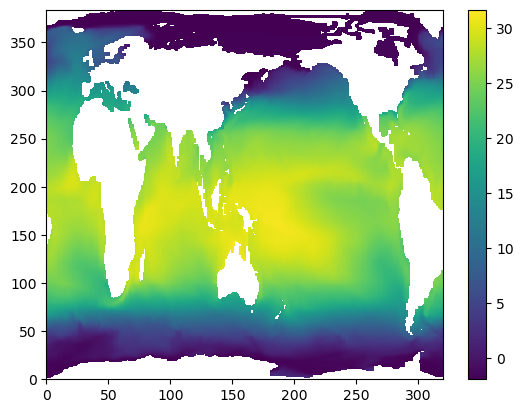

In [11]:
pl.pcolor(SST[0,0,...]); pl.colorbar()

### <span style="color:blue">Interpolate data to a grid we can more easily manage</span>

In [12]:
TLONG = ma.masked_where(TLONG==TLONG.max(), TLONG); TLAT = ma.masked_where(TLAT==TLAT.max(),TLAT)

In [13]:
#this will define the lat/lon range we will be using
x = np.linspace(0,360,360)
y =  np.linspace(-80,90,170)
#this will put lat and lon into arrays, something that is needed for plotting
X, Y = np.meshgrid(x,y)
#here we are regridding the data to the latitude/longitude we want
SST_test = griddata((TLONG.flatten(),TLAT.flatten()), SST[0,0,...].flatten(), (X, Y), method='nearest')
SST_test = ma.masked_where(SST_test==SST_test.max(),SST_test)

### <span style="color:blue">Make some sample plots, find some longitude/latitude ranges to work with</span>

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\2804492987.py:7: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cb = pl.colorbar(shrink=0.7); cb.set_label('$^o$C',fontsize=12)
C:\Users\tianq\anaconda3\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


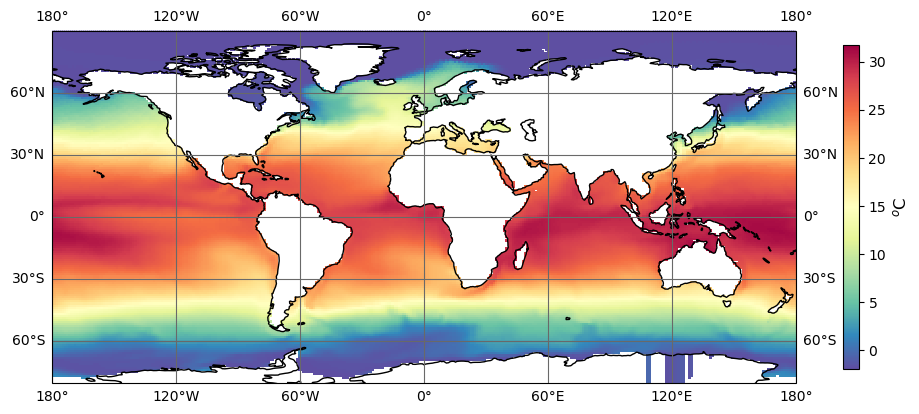

In [14]:
pl.figure(figsize=(12,6))
ax = pl.subplot(1,1,1,projection=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,color='dimgray')
gl.xlabels_bottom = False; gl.ylabels_right = False
pl.pcolor(X,Y,SST_test,cmap='Spectral_r')
cb = pl.colorbar(shrink=0.7); cb.set_label('$^o$C',fontsize=12)


In [15]:
#Finding latitudes/longitudes for the Gulf of Maine
latmin = 39; latmax = 45
lonmin=285; lonmax = 295

In [16]:
# Getting the latitude index
y1 = (np.abs(Y[:,0]-latmin)).argmin(); y2 = (np.abs(Y[:,0]-latmax)).argmin()
#
x1 = (np.abs(X[0,:]-lonmin)).argmin(); x2 = (np.abs(X[0,:]-lonmax)).argmin()

In [17]:
# Extracting the area we want
SST_test_GoME = SST_test[y1:y2+1,x1:x2+1]

In [18]:
lat_GoME = Y[y1:y2+1,x1:x2+1]; lon_GoME = X[y1:y2+1,x1:x2+1]

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\2899622303.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cb = pl.colorbar(shrink=0.5); cb.set_label('$^o$C',fontsize=12)
C:\Users\tianq\anaconda3\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


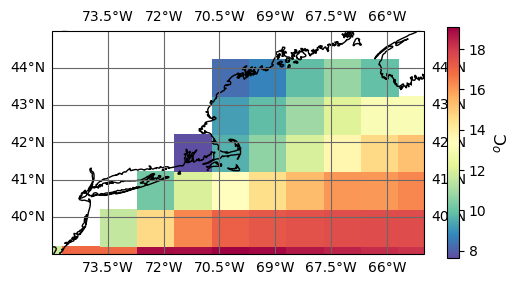

In [19]:
pl.figure(figsize=(6,6))
ax = pl.subplot(1,1,1,projection=ccrs.PlateCarree())
ax.set_extent([285,295,39,45])
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,color='dimgray')
gl.xlabels_bottom = False; gl.ylabels_right = False
pl.pcolor(lon_GoME,lat_GoME,SST_test_GoME,cmap='Spectral_r')
cb = pl.colorbar(shrink=0.5); cb.set_label('$^o$C',fontsize=12)


# <span style="color:darkblue">Performing a time series analysis</span>

## <span style="color:darkgreen">1. Loading all the files</span>

In [20]:
file = nc.Dataset(filelist[0],'r')
sst_all_orig = file.variables['SST'][:]
time_all = file.variables['time'][:]

In [21]:
for f in filelist[1::]:
    file = nc.Dataset(f,'r')
    sst_all_orig = np.concatenate((sst_all_orig,file.variables['SST'][:]),0)
    time_all = np.concatenate((time_all,file.variables['time'][:]),0)

## <span style="color:darkgreen">2. Converting the dates and interpolating SST to the grid we created</span>

In [22]:
date_all = []
for i in range(len(time_all)):
    date_all.append(convert_partial_year((time_all[i]-15)/365))
date_all = np.array(date_all)

In [24]:
sst_all = []
for i in range(len(time_all)):
    sst_all.append(griddata((TLONG.flatten(),TLAT.flatten()), sst_all_orig[i,0,...].flatten(), (X, Y), method='nearest'))
sst_all = np.array(sst_all)

## <span style="color:darkgreen">3. Select the area I want to work with</span>

In [25]:
sst_GoME = sst_all[:,y1:y2+1,x1:x2+1]

In [630]:
lat_GoME = Y[y1:y2+1,0]; lon_GoME = X[0,x1:x2+1]

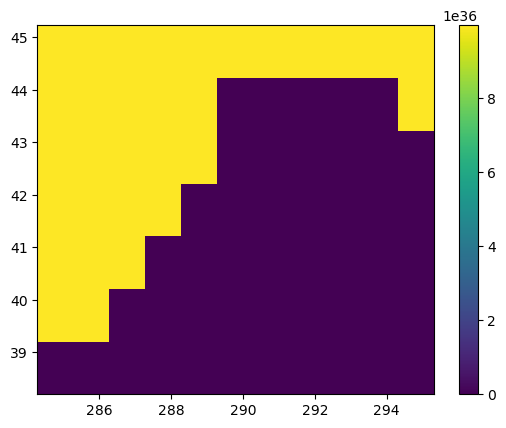

In [26]:
pl.pcolor(lon_GoME,lat_GoME,sst_GoME[0,...]); pl.colorbar()

In [27]:
sst_GoME = ma.masked_where(sst_GoME==sst_GoME.max(),sst_GoME)

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\2035197866.py:1: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(sst_GoME[0,...]); pl.colorbar()


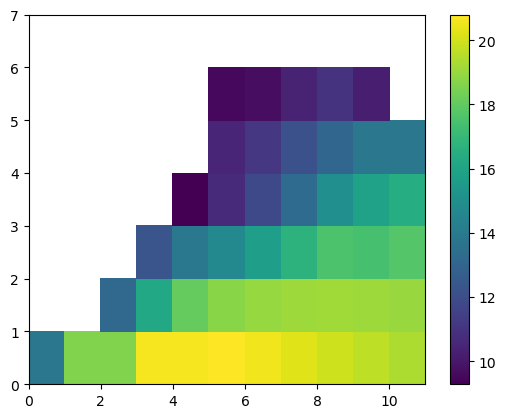

In [28]:
pl.pcolor(sst_GoME[0,...]); pl.colorbar()

## <span style="color:darkgreen">4. Plot average SST with time</span>

In [29]:
# calculate mean SST
sst_GoME_mean = ma.mean(sst_GoME,axis=(1,2))

(-43812.999999999985, -36539.00000000004)

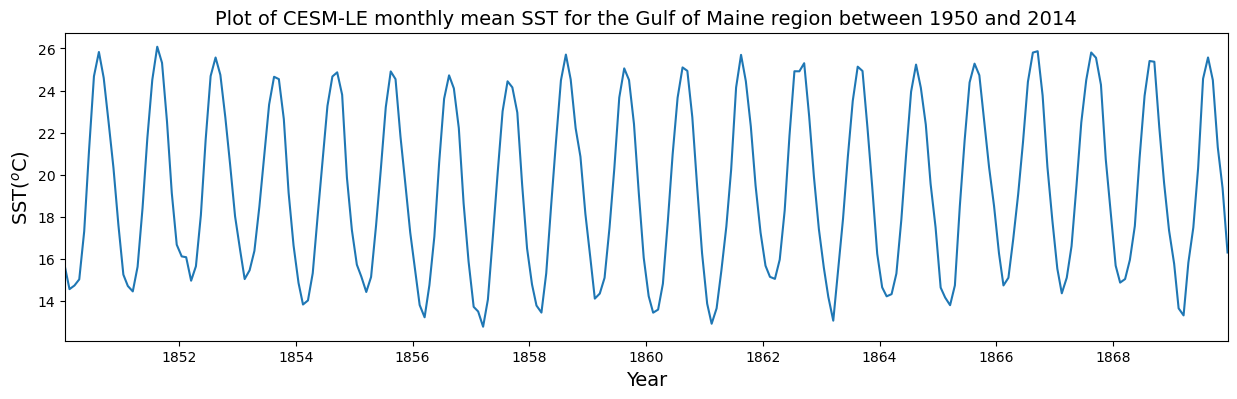

In [32]:
pl.figure(figsize=(15,4))
pl.plot(date_all,sst_GoME_mean)
pl.title('Plot of CESM-LE monthly mean SST for the Gulf of Maine region between 1950 and 2014',fontsize=14)
pl.ylabel('SST($^o$C)',fontsize=14); pl.xlabel('Year',fontsize=14)
pl.xlim((date_all[0],date_all[-1]))

## <span style="color:darkgreen">5. Calculate yearly means, climatology, and anomalies</span>

In [33]:
# Make an array of years and months
years = []; months = []
for t in range(len(time_all)):
    years.append(date_all[t].year); months.append(date_all[t].month)
years = np.array(years); months = np.array(months)

In [34]:
# Calculating yearly mean
yrange = np.arange(1850,2015)
sst_GoME_ymean = []
for yr in yrange:
    msk = years==yr
    sst_GoME_ymean.append(ma.mean(sst_GoME[msk,...],axis=0))
sst_GoME_ymean = ma.array(sst_GoME_ymean)
sst_GoME_ymean = ma.masked_where(sst_GoME_ymean==sst_GoME_ymean.max(),sst_GoME_ymean)

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\3298115814.py:1: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(sst_GoME_ymean[0,...]); pl.colorbar()


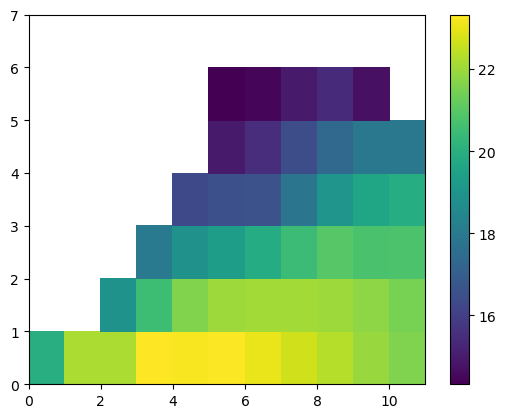

In [35]:
pl.pcolor(sst_GoME_ymean[0,...]); pl.colorbar()

Text(0.5, 1.0, 'CESM-LE yearly mean SST for the Gulf of Maine')

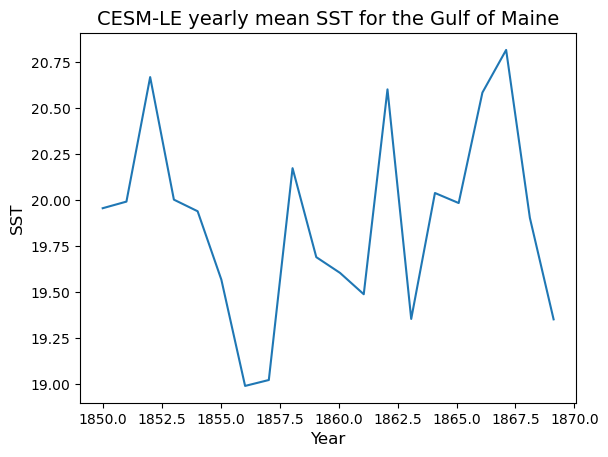

In [46]:
pl.plot(np.arange(1850,2015), sst_GoME_ymean[:,0,0])
pl.ylabel('SST',fontsize=12); pl.xlabel('Year',fontsize=12)
pl.title('CESM-LE yearly mean SST for the Gulf of Maine',fontsize=14)

Here we will calculate the climatology for the whole time series, and a separate one just for the pre-industrial period. Steps to calculate climatology:

    1. create a "mask" that chooses all the time indices for each month
    
    2. calculate the mean for that month
    
    3. Add to the climatology variable
 

In [47]:
# Calculating monthly climatology for the whole period
sst_GoME_clim = []
for mt in range(1,13):
    msk = months==mt
    sst_GoME_clim.append(ma.mean(sst_GoME[msk,...],axis=0))
sst_GoME_clim = ma.array(sst_GoME_clim)
sst_GoME_clim = ma.masked_where(sst_GoME_clim==sst_GoME_clim.max(),sst_GoME_clim)

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\2282814585.py:3: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(sst_GoME_clim[0,...],vmin=8,vmax=26, cmap='Spectral_r'); pl.colorbar()
C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\2282814585.py:6: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(sst_GoME_clim[6,...],vmin=8,vmax=26, cmap='Spectral_r'); pl.colorbar()


Text(0.5, 1.0, 'Gulf of Maine SST in July')

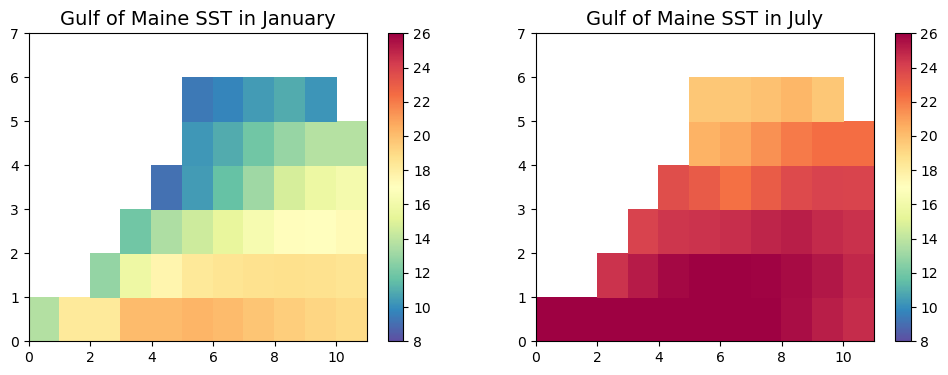

In [48]:
pl.figure(figsize=(12,4))
pl.subplot(1,2,1)
pl.pcolor(sst_GoME_clim[0,...],vmin=8,vmax=26, cmap='Spectral_r'); pl.colorbar()
pl.title('Gulf of Maine SST in January', fontsize=14)
pl.subplot(1,2,2)
pl.pcolor(sst_GoME_clim[6,...],vmin=8,vmax=26, cmap='Spectral_r'); pl.colorbar()
pl.title('Gulf of Maine SST in July', fontsize=14)

Now we will calculate the anomalies relative to the whole period, and relative to the pre-industrial baseline.To calculate the anomalies, the steps are:

    1. Find the month at each time

    2. Subtract the climatological mean of that month

    3. Add to the anomaly file

In [49]:
# Calculating anomalies relative to the whole period
sst_GoME_anom = []
for i in range(len(date_all)):
    mi = months[i]-1
    sst_GoME_anom.append(sst_GoME[i,...]-sst_GoME_clim[mi,...])
sst_GoME_anom = ma.array(sst_GoME_anom)
sst_GoME_anom = ma.masked_where(sst_GoME_anom==sst_GoME_anom.max(),sst_GoME_anom)

C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\3126754558.py:3: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(sst_GoME_anom[0,...],vmin=-1,vmax=1,cmap='coolwarm'); pl.colorbar(); pl.title('01/1850',fontsize=14)
C:\Users\tianq\AppData\Local\Temp\ipykernel_16816\3126754558.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  pl.pcolor(sst_GoME_anom[-1,...],vmin=-2,vmax=2,cmap='coolwarm'); pl.colorbar(); pl.title('12/2014',fontsize=14)


Text(0.5, 1.0, '12/2014')

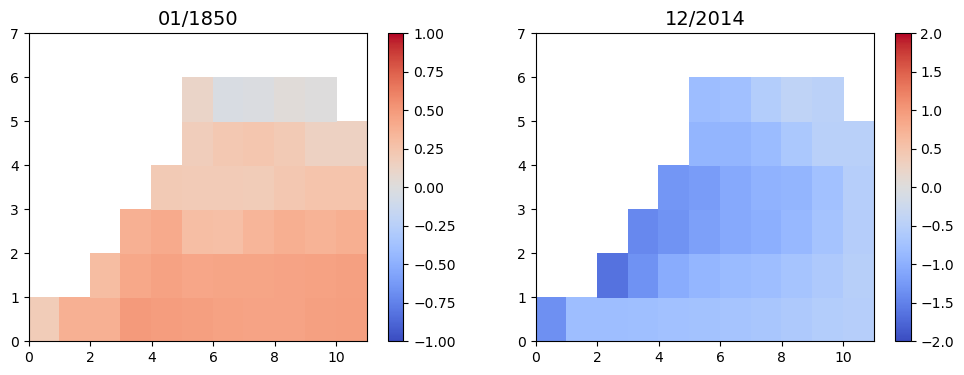

In [50]:
pl.figure(figsize=(12,4))
pl.subplot(1,2,1)
pl.pcolor(sst_GoME_anom[0,...],vmin=-1,vmax=1,cmap='coolwarm'); pl.colorbar(); pl.title('01/1850',fontsize=14)
pl.subplot(1,2,2)
pl.pcolor(sst_GoME_anom[-1,...],vmin=-2,vmax=2,cmap='coolwarm'); pl.colorbar(); pl.title('12/2014',fontsize=14)

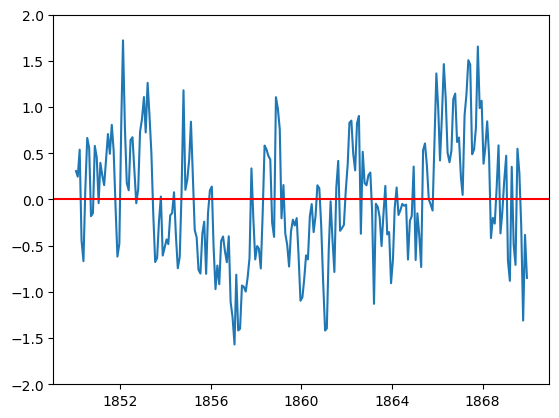

In [45]:
pl.plot(date_all,ma.mean(sst_GoME_anom,axis=(1,2)))
pl.ylim((-2,2)); pl.axhline(y = 0, color = 'r', linestyle = '-') 

## <span style="color:darkgreen">5. Calculate linear regression</span>

### <span style="color:green">5.1 For the whole period</span>

In [51]:
#total yearly mean
sst_GoME_amean = ma.mean(sst_GoME_ymean,axis=(1,2))
# Fit a polynomial of degree 1 (linear regression)
coefficients = np.polyfit(yrange, sst_GoME_amean, 1)
# Extract slope (m) and intercept (b)
m, b = coefficients
# Create a line for plotting
regression_line = m *yrange  + b

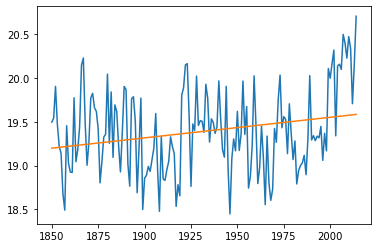

In [646]:
pl.plot(yrange,sst_GoME_amean); 
pl.plot(yrange,regression_line)

### <span style="color:green">5.2 For 1850-1900</span>

In [52]:
yrange = np.arange(1850,2015)

In [53]:
# Pick the data up to 1900
sst_GoME_1850 = sst_GoME_ymean[yrange<=1900,...]
# calculate area mean
sst_GoME_1850 = ma.mean(sst_GoME_1850,axis=(1,2))
# Fit a polynomial of degree 1 (linear regression)
coefficients = np.polyfit(yrange[0:51], sst_GoME_1850, 1)
# Extract slope (m) and intercept (b)
m1850, b1850 = coefficients
# Create a line for plotting
regression_line1850 = m1850 *yrange[0:51]  + b1850

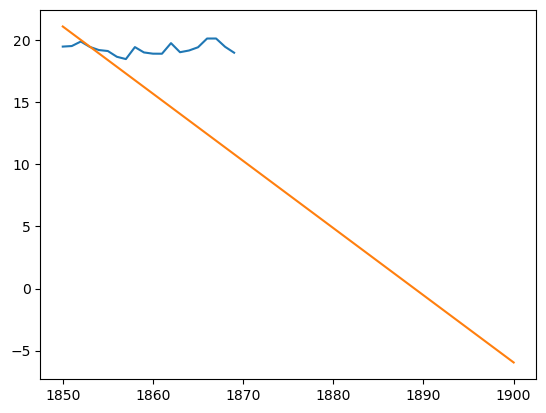

In [54]:
pl.plot(yrange[0:51],sst_GoME_1850); 
pl.plot(yrange[0:51],regression_line1850)

### <span style="color:green">5.3 For 1964-2014</span>

In [650]:
# Pick the data starting in 1964
sst_GoME_1964 = sst_GoME_ymean[yrange>=1964,...]
# calculate area mean
sst_GoME_1964 = ma.mean(sst_GoME_1964,axis=(1,2))
# Fit a polynomial of degree 1 (linear regression)
coefficients = np.polyfit(yrange[-51::], sst_GoME_1964, 1)
# Extract slope (m) and intercept (b)
m1964, b1964 = coefficients
# Create a line for plotting
regression_line1964 = m1964 *yrange[-51::]  + b1964

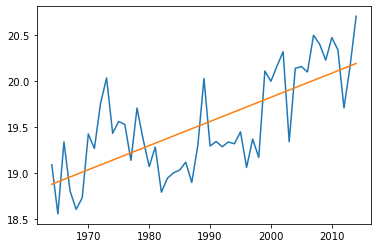

In [651]:
pl.plot(yrange[-51::],sst_GoME_1964); 
pl.plot(yrange[-51::],regression_line1964)

In [652]:
print("The heating rate for Gulf of Maine is:")
print('For the whole period:'+str(m)+' oC/year')
print('For the 1850-1900 period:'+str(m1850)+' oC/year')
print('For the 1964-2014 period:'+str(m1964)+' oC/year')

The heating rate for Gulf of Maine is:
For the whole period:0.0023504411717003414 oC/year
For the 1850-1900 period:-0.0007685914015533011 oC/year
For the 1964-2014 period:0.02631435057371012 oC/year


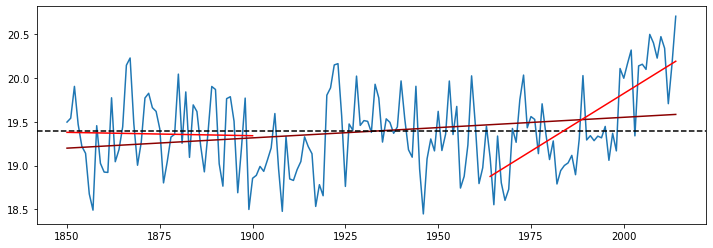

In [653]:
pl.figure(figsize=(12,4))
pl.plot(yrange,sst_GoME_amean); pl.plot(yrange,regression_line,color='darkred')
pl.axhline(y = np.mean(sst_GoME_amean), color = 'k', linestyle = '--') 
pl.plot(yrange[0:51],regression_line1850,color='r')
pl.plot(yrange[-51::],regression_line1964,color='r')

## <span style="color:darkgreen">6. Plot histograms for each period</span>

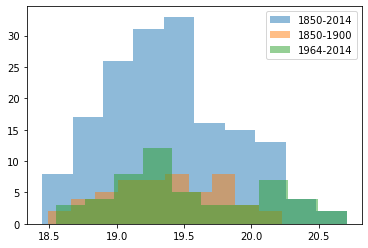

In [654]:
# Annual means
pl.hist(sst_GoME_amean,alpha=0.5,label='1850-2014')
pl.hist(sst_GoME_1850,alpha=0.5, label='1850-1900')
pl.hist(sst_GoME_1964,alpha=0.5, label='1964-2014')
pl.legend()

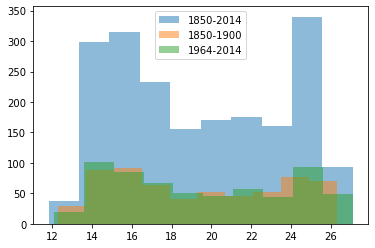

In [655]:
###### Monthly means #######
# Select the months you want
sst_GoME_mmean1850 = sst_GoME[years<=1900,...]; sst_GoME_mmean1964 = sst_GoME[years>=1964,...]
# Plot
pl.hist(ma.mean(sst_GoME,axis=(1,2)),alpha=0.5,label='1850-2014')
pl.hist(ma.mean(sst_GoME_mmean1850,axis=(1,2)),alpha=0.5, label='1850-1900')
pl.hist(ma.mean(sst_GoME_mmean1964,axis=(1,2)),alpha=0.5, label='1964-2014')
pl.legend()

## <span style="color:darkgreen">7. Calculate time of emergence</span>

In [656]:
sst_GoME_sdev = ma.std(sst_GoME_amean)

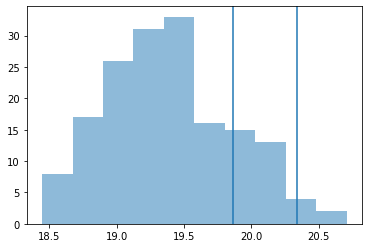

In [657]:
pl.hist(sst_GoME_amean,alpha=0.5)
pl.axvline(x=(np.mean(sst_GoME_amean)+sst_GoME_sdev))
pl.axvline(x=(np.mean(sst_GoME_amean)+2*sst_GoME_sdev))

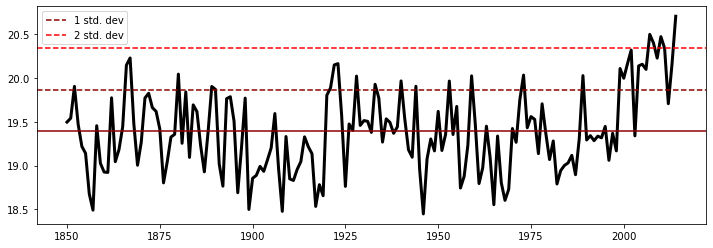

In [658]:
pl.figure(figsize=(12,4))
pl.plot(yrange,sst_GoME_amean,linewidth=3,color='k')
pl.axhline(y = np.mean(sst_GoME_amean), color = 'darkred', linestyle = '-') 
pl.axhline(y = (np.mean(sst_GoME_amean)+sst_GoME_sdev), color = 'darkred', linestyle = '--',label='1 std. dev') 
pl.axhline(y = (np.mean(sst_GoME_amean)+2*sst_GoME_sdev), color = 'red', linestyle = '--',label='2 std. dev') 
pl.legend()

In [659]:
y_emtrend_2sdev = np.where(sst_GoME_amean>=(np.mean(sst_GoME_amean)+2*sst_GoME_sdev))

In [660]:
yrange[y_emtrend_2sdev]

array([2007, 2008, 2010, 2011, 2014])

In [661]:
y_emtrend_sdev = np.where(sst_GoME_amean>=(np.mean(sst_GoME_amean)+sst_GoME_sdev))

In [662]:
yrange[y_emtrend_sdev]

array([1852, 1866, 1867, 1880, 1889, 1890, 1921, 1922, 1923, 1928, 1933,
       1940, 1944, 1953, 1959, 1973, 1989, 1999, 2000, 2001, 2002, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2013, 2014])